# EEEM068 - Multi-View ViT-Small + SiT-S - Part 4

**Scope:** End-to-end training loop, TensorBoard, and training curves

**Source notebook:** `EEEM068_SiT_S_Final_FIXED (2).ipynb`

**Notes**
- This notebook is a split component of the original final notebook.
- Some setup cells are intentionally repeated so each part is easier to understand in isolation.
- If you want to run the full pipeline end-to-end, use the original notebook or follow the README in sequence.

# EEEM068 — Knee MRI Classification · ViT-Small + SiT-S
**University of Surrey — Applied Machine Learning (Spring 2026)**

| Item | Detail |
|---|---|
| Model | Multi-View ViT-Small patch16/224 (shared backbone, 3 planes) |
| Pretrained weights | **SiT-S** — Sara Ahmed et al. 2021 (self-supervised ImageNet) |
| Dataset | MRNet — 1,370 knee MRI exams (Stanford University Medical Center) |
| Task | Multi-label: ACL tear · Meniscus tear · Abnormal |
| Loss | Focal BCE (γ=0.5) + Label smoothing + MixUp |

**Run order:** Execute cells top-to-bottom. Edit only the two paths in Section 1.

---


## Section 1 — Imports & Configuration

In [1]:
import os, io, gc, math, pickle, random, warnings, urllib.request
from pathlib import Path
from io import BytesIO
from collections import deque, OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms as T
import timm

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

print(f"PyTorch : {torch.__version__}")
print(f"timm    : {timm.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


PyTorch : 2.11.0+cu130
timm    : 1.0.27
CUDA    : True
GPU     : NVIDIA RTX A4000
VRAM    : 16.7 GB


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — fixed for your Surrey/otter AML folder
# ══════════════════════════════════════════════════════════════════════════════
class CFG:
    # ── MAIN PROJECT PATHS ────────────────────────────────────────────────────
    AML_DIR = Path("/user/HS402/mi00806/Downloads/AML")

    ROOT    = Path("/user/HS402/mi00806/.cache/kagglehub/datasets/"
                   "cjinny/mrnet-v1/versions/1/MRNet-v1.0")
    OUT_DIR = AML_DIR / "mrnet_outputs"

    # Your real downloaded SiT-S checkpoints are inside AML/sit_zip/
    SIT_DIR = AML_DIR / "sit_zip"
    SIT_VARIANT = "ImageNet"   # options: ImageNet, Pascal, Pets, STL10
    SIT_CACHE_PATH = str(SIT_DIR / f"SiT_Small_{SIT_VARIANT}.pth")

    CHECKPOINT_PATH = str(OUT_DIR / "best_vit.pth")
    TENSORBOARD_DIR = str(OUT_DIR / "tb_logs")

    IMAGE_SIZE  = 224
    MODEL_NAME  = "vit_small_patch16_224"
    NUM_CLASSES = 3
    LABEL_NAMES = ["acl", "meniscus", "abnormal"]

    TOP_K_SLICES = 5
    N_CHANNELS   = 3

    BATCH_SIZE  = 8
    EPOCHS      = 60
    MIN_EPOCHS  = 20
    PATIENCE    = 15
    NUM_WORKERS = 4
    SEED        = 42

    HEAD_LR           = 1e-3
    BACKBONE_LR_LATE  = 1e-5
    BACKBONE_LR_EARLY = 5e-6
    WEIGHT_DECAY      = 1e-4

    UNFREEZE_PARTIAL_EP = 5
    UNFREEZE_FULL_EP    = 10
    N_BLOCKS_PARTIAL    = 6
    WARMUP_EPOCHS       = 3
    WARMUP_RESTART      = 2

    DROP_PATH_RATE = 0.1
    DROPOUT_HEAD1  = 0.3
    DROPOUT_HEAD2  = 0.15
    LABEL_SMOOTH   = 0.05
    MIXUP_ALPHA    = 0.2
    MIXUP_PROB     = 0.4
    MIXUP_START_EP = UNFREEZE_PARTIAL_EP + 1

    FOCAL_GAMMA = 0.5
    FOCAL_ALPHA = [0.82, 0.63, 0.19]

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CFG.OUT_DIR.mkdir(parents=True, exist_ok=True)

assert CFG.ROOT.exists(), f"Dataset not found: {CFG.ROOT}"
assert Path(CFG.SIT_CACHE_PATH).exists(), (
    f"SiT checkpoint not found: {CFG.SIT_CACHE_PATH}\n"
    f"Your downloaded files should be in: {CFG.SIT_DIR}\n"
    "Run: ls -lh /user/HS402/mi00806/Downloads/AML/sit_zip/"
)

print("CFG loaded ✅")
print(f"  Device     : {CFG.DEVICE}")
print(f"  Dataset    : {CFG.ROOT}")
print(f"  Out dir    : {CFG.OUT_DIR}")
print(f"  SiT weights: {CFG.SIT_CACHE_PATH}")
print(f"  SiT size   : {Path(CFG.SIT_CACHE_PATH).stat().st_size/1e6:.1f} MB")


CFG loaded ✅
  Device     : cuda
  Dataset    : /user/HS402/mi00806/.cache/kagglehub/datasets/cjinny/mrnet-v1/versions/1/MRNet-v1.0
  Out dir    : /user/HS402/mi00806/Downloads/AML/mrnet_outputs
  SiT weights: /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_ImageNet.pth
  SiT size   : 669.7 MB


## Section 2 — SiT-S Weights: Load Local Checkpoint

This version is fixed for your current folder structure.

Your real checkpoint files are already downloaded in:

```text
/user/HS402/mi00806/Downloads/AML/sit_zip/
```

The notebook now loads:

```text
SiT_Small_ImageNet.pth
```

So it will no longer look for the missing `../sit_extracted/` folder.


In [3]:
# ── SiT-S checkpoint load from your local sit_zip folder ──────────────────────
# Your downloaded files:
#   /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_ImageNet.pth
#   /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_Pascal.pth
#   /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_Pets.pth
#   /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_STL10.pth

SIT_CACHE = Path(CFG.SIT_CACHE_PATH)


def load_sit_checkpoint(path):
    """Load a local SiT checkpoint safely."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {path}")

    size_mb = path.stat().st_size / 1e6
    print(f"  File: {path}")
    print(f"  Size: {size_mb:.1f} MB")

    if size_mb < 100:
        raise RuntimeError(
            f"This checkpoint is too small ({size_mb:.1f} MB).\n"
            "Use the real downloaded checkpoint in AML/sit_zip/, not data.pkl or sit_small.pth."
        )

    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    print("  ✅ torch.load: OK")
    return ckpt


def extract_sit_state_dict(ckpt, ref_keys):
    """Find and clean the state dict from the SiT checkpoint."""
    ref_keys = set(ref_keys)

    candidates = {}
    if isinstance(ckpt, dict):
        for k in ["student", "teacher", "model", "state_dict", "module", "backbone"]:
            if k in ckpt and isinstance(ckpt[k], dict):
                candidates[k] = ckpt[k]
        if not candidates:
            candidates["<root>"] = ckpt
    else:
        raise TypeError(f"Unexpected checkpoint type: {type(ckpt)}")

    best_n, best_key, best_state = 0, None, None

    prefixes = [
        "module.backbone.",
        "module.student.backbone.",
        "student.backbone.",
        "teacher.backbone.",
        "backbone.",
        "module.",
    ]

    for key, state in candidates.items():
        cleaned = {}
        for k, v in state.items():
            new_k = k
            for prefix in prefixes:
                if new_k.startswith(prefix):
                    new_k = new_k[len(prefix):]
            cleaned[new_k] = v

        n = len(ref_keys & set(cleaned.keys()))
        print(f"  key='{key}': {n}/{len(ref_keys)} keys match timm ViT-Small")

        if n > best_n:
            best_n, best_key, best_state = n, key, cleaned

    return best_key, best_state, best_n


def check_nan(state_dict):
    """Return list of keys with NaN values."""
    nan_keys = []
    for k, v in state_dict.items():
        if torch.is_tensor(v) and torch.isnan(v.float()).any():
            nan_keys.append(k)
    return nan_keys


# ── STEP 1: Use local checkpoint ──────────────────────────────────────────────
print("=" * 60)
print("STEP 1 — Using local SiT-S checkpoint")
print("=" * 60)
print(f"✅ Using: {SIT_CACHE}")

# ── STEP 2: Load and inspect ─────────────────────────────────────────────────
print()
print("=" * 60)
print("STEP 2 — Loading and inspecting checkpoint")
print("=" * 60)

raw_ckpt = load_sit_checkpoint(SIT_CACHE)
if isinstance(raw_ckpt, dict):
    print(f"Top-level keys: {list(raw_ckpt.keys())[:20]}")
    if "epoch" in raw_ckpt:
        print(f"Saved at epoch: {raw_ckpt['epoch']}")

# ── STEP 3: Build reference model and match keys ──────────────────────────────
print()
print("=" * 60)
print("STEP 3 — Matching keys to timm ViT-Small")
print("=" * 60)

_ref = timm.create_model(CFG.MODEL_NAME, pretrained=False, num_classes=0)
ref_keys = list(_ref.state_dict().keys())
print(f"timm ViT-Small has {len(ref_keys)} parameter tensors")

best_key, best_state, n_matched = extract_sit_state_dict(raw_ckpt, ref_keys)
del _ref

print(f"\nBest match: key='{best_key}'  {n_matched}/{len(ref_keys)} keys matched")

# ── STEP 4: Check health ─────────────────────────────────────────────────────
print()
print("=" * 60)
print("STEP 4 — NaN / health check")
print("=" * 60)

if best_state is not None and n_matched > 10:
    nan_keys = check_nan(best_state)
    print(f"NaN tensors: {len(nan_keys)} / {len(best_state)}")

    if nan_keys:
        print(f"NaN keys first 5: {nan_keys[:5]}")
        SIT_WEIGHTS_OK = False
        print("⚠️ SiT weights are not healthy, notebook will fall back to timm ImageNet.")
    else:
        SIT_WEIGHTS_OK = True
        print("✅ SiT checkpoint is healthy and ready to load")
else:
    SIT_WEIGHTS_OK = False
    print(f"⚠️ Only {n_matched} keys matched — notebook will fall back to timm ImageNet.")

print(f"\nSIT_WEIGHTS_OK = {SIT_WEIGHTS_OK}")


STEP 1 — Using local SiT-S checkpoint
✅ Using: /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_ImageNet.pth

STEP 2 — Loading and inspecting checkpoint
  File: /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_ImageNet.pth
  Size: 669.7 MB
  ✅ torch.load: OK
Top-level keys: ['student', 'teacher', 'optimizer', 'epoch', 'args', 'fp16_scaler']
Saved at epoch: 715

STEP 3 — Matching keys to timm ViT-Small
timm ViT-Small has 150 parameter tensors
  key='student': 150/150 keys match timm ViT-Small
  key='teacher': 150/150 keys match timm ViT-Small

Best match: key='student'  150/150 keys matched

STEP 4 — NaN / health check
NaN tensors: 0 / 177
✅ SiT checkpoint is healthy and ready to load

SIT_WEIGHTS_OK = True


## Section 3 — Model: MultiViewViT

**Architecture:** One shared ViT-Small backbone processes all three MRI planes
independently. Each plane produces a 384-dim CLS token. Three tokens are
concatenated → 1152-dim → MLP head → 3 output logits.

**Weight loading priority:**
1. SiT-S from Sara Ahmed et al. (self-supervised ImageNet, recommended by spec)
2. timm supervised ImageNet (fallback if SiT download fails)

The model clearly reports which source was used via `model.pretrained_source`.


In [4]:
class MultiViewViT(nn.Module):
    """Multi-view ViT-Small for knee MRI multi-label classification.

    One shared backbone encodes sagittal, coronal and axial planes independently.
    CLS outputs [B,384] x3 concatenated to [B,1152] → MLP head → [B,3] logits.
    """

    def __init__(self, num_classes=CFG.NUM_CLASSES):
        super().__init__()
        self.backbone = timm.create_model(
            CFG.MODEL_NAME, pretrained=False, num_classes=0,
            drop_path_rate=CFG.DROP_PATH_RATE
        )
        D = self.backbone.num_features  # 384 for ViT-Small

        self.head = nn.Sequential(
            nn.LayerNorm(D * 3),
            nn.Linear(D * 3, 512), nn.GELU(), nn.Dropout(CFG.DROPOUT_HEAD1),
            nn.Linear(512, 256),   nn.GELU(), nn.Dropout(CFG.DROPOUT_HEAD2),
            nn.Linear(256, num_classes),
        )
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, sag, cor, axi):
        feats = torch.cat([self.backbone(sag),
                           self.backbone(cor),
                           self.backbone(axi)], dim=1)
        return self.head(feats)

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False

    def unfreeze_last_n_blocks(self, n):
        for p in self.backbone.parameters(): p.requires_grad = False
        for block in list(self.backbone.blocks)[-n:]:
            for p in block.parameters(): p.requires_grad = True
        for p in self.backbone.norm.parameters(): p.requires_grad = True

    def unfreeze_all(self):
        for p in self.backbone.parameters(): p.requires_grad = True

    def trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def get_param_groups(self, head_lr, bb_early_lr, bb_late_lr, wd):
        blocks       = list(self.backbone.blocks)
        half         = len(blocks) // 2
        early_params = [p for b in blocks[:half] for p in b.parameters()]
        late_params  = [p for b in blocks[half:] for p in b.parameters()]
        extra_early  = (list(self.backbone.patch_embed.parameters()) +
                        [self.backbone.cls_token, self.backbone.pos_embed])
        return [
            {"params": self.head.parameters(),
             "lr": head_lr,     "weight_decay": wd},
            {"params": late_params + list(self.backbone.norm.parameters()),
             "lr": bb_late_lr,  "weight_decay": wd},
            {"params": early_params + extra_early,
             "lr": bb_early_lr, "weight_decay": wd},
        ]


# ── Build model ───────────────────────────────────────────────────────────────
model = MultiViewViT().to(CFG.DEVICE)

if SIT_WEIGHTS_OK and best_state is not None:
    # ── Load SiT-S weights ─────────────────────────────────────────────────────
    msg = model.backbone.load_state_dict(best_state, strict=False)
    model.pretrained_source = "SiT-S (Sara Ahmed et al. 2021, self-supervised ImageNet)"
    print(f"✅ SiT-S weights loaded")
    print(f"   Matched   : {n_matched}/{len(ref_keys)}")
    print(f"   Missing   : {len(msg.missing_keys)}")
    print(f"   Unexpected: {len(msg.unexpected_keys)}")
else:
    # ── Fallback: timm supervised ImageNet ────────────────────────────────────
    print("Loading timm supervised ImageNet weights (SiT-S unavailable)...")
    sup = timm.create_model(CFG.MODEL_NAME, pretrained=True, num_classes=0,
                            drop_path_rate=CFG.DROP_PATH_RATE)
    model.backbone.load_state_dict(sup.state_dict(), strict=True)
    del sup
    model.pretrained_source = "timm supervised ImageNet (SiT-S download failed)"
    print(f"⚠️  Using ImageNet weights — see Section 2 to fix SiT-S download")

# ── Assert zero NaN weights ───────────────────────────────────────────────────
nan_count = sum(1 for p in model.parameters() if p.isnan().any())
assert nan_count == 0, (
    f"{nan_count} NaN parameter tensors detected — "
    "weights did not load correctly. Re-run Section 2."
)

# ── Forward pass sanity check ─────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    x     = torch.randn(2, 3, 224, 224).to(CFG.DEVICE)
    probs = torch.sigmoid(model(x, x, x))
    mean_p = probs.mean().item()

print(f"\nPretrained source : {model.pretrained_source}")
print(f"Total parameters  : {sum(p.numel() for p in model.parameters()):,}")
print(f"Forward pass probs: {probs.cpu().numpy().round(3)}")
if 0.05 < mean_p < 0.95:
    print(f"✅ mean prob = {mean_p:.3f} — healthy")
else:
    print(f"⚠️  mean prob = {mean_p:.3f} — COLLAPSED — weights broken")


✅ SiT-S weights loaded
   Matched   : 150/150
   Missing   : 0
   Unexpected: 27

Pretrained source : SiT-S (Sara Ahmed et al. 2021, self-supervised ImageNet)
Total parameters  : 22,390,403
Forward pass probs: [[0.322 0.431 0.495]
 [0.326 0.435 0.49 ]]
✅ mean prob = 0.416 — healthy


## Section 4 — Dataset Labels & Stratified Split

MRNet provides three CSV files (one per condition) for the train split.
Labels: ACL tear, Meniscus tear, Abnormal (multi-label — not mutually exclusive).
We perform a **stratified 85/15 split** on the `abnormal` label.


In [5]:
def load_labels(root, split):
    """Load and merge ACL / Abnormal / Meniscus CSVs into one DataFrame."""
    acl      = pd.read_csv(root / f"{split}-acl.csv",
                           header=None, names=["id", "acl"])
    abnormal = pd.read_csv(root / f"{split}-abnormal.csv",
                           header=None, names=["id", "abnormal"])
    meniscus = pd.read_csv(root / f"{split}-meniscus.csv",
                           header=None, names=["id", "meniscus"])
    df = acl.merge(abnormal, on="id").merge(meniscus, on="id")
    df["id"] = df["id"].astype(str).str.zfill(4)
    for plane in ["sagittal", "coronal", "axial"]:
        df[f"{plane}_path"] = df["id"].apply(
            lambda x, p=plane: str(root / "train" / p / f"{x}.npy"))
    df["target"] = df.apply(
        lambda r: [float(r["acl"]),
                   float(r["meniscus"]),
                   float(r["abnormal"])], axis=1)
    return df


all_df = load_labels(CFG.ROOT, "train")
train_df, valid_df = train_test_split(
    all_df, test_size=0.15, random_state=CFG.SEED,
    stratify=all_df["abnormal"].astype(int)
)
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print(f"Train : {len(train_df)} scans")
print(f"Valid : {len(valid_df)} scans  (15% stratified split)")
print()
print("Label distribution:")
for lbl in CFG.LABEL_NAMES:
    tr_n = int(train_df[lbl].sum())
    va_n = int(valid_df[lbl].sum())
    print(f"  {lbl:>10}:  "
          f"train {tr_n:>3} pos ({100*tr_n/len(train_df):.1f}%)  "
          f"| valid {va_n:>3} pos ({100*va_n/len(valid_df):.1f}%)")


Train : 960 scans
Valid : 170 scans  (15% stratified split)

Label distribution:
         acl:  train 185 pos (19.3%)  | valid  23 pos (13.5%)
    meniscus:  train 328 pos (34.2%)  | valid  69 pos (40.6%)
    abnormal:  train 776 pos (80.8%)  | valid 137 pos (80.6%)


## Section 6 — Preprocessing & Dataset Class

**Slice selection:** Top-5 variance slices selected per volume → 3 chosen
evenly → stacked as pseudo-RGB image. High-variance slices contain structural
detail rather than blank background.

**Augmentation (train only):** rotation ±20°, translation ±10%,
scale 85–115%, horizontal flip, colour jitter.


In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def select_topk_variance_slices(volume, top_k=5, n_out=3):
    D   = volume.shape[0]
    var = np.var(volume.reshape(D,-1), axis=1)
    topk = np.sort(np.argsort(var)[-min(top_k,D):])
    n_out = min(n_out, len(topk))
    chosen = topk[np.linspace(0, len(topk)-1, n_out, dtype=int)]
    if len(chosen) < n_out:
        chosen = np.pad(chosen, (0, n_out-len(chosen)), mode="edge")
    return volume[chosen]


def volume_to_rgb(volume, top_k=5, n_ch=3):
    slices = select_topk_variance_slices(volume, top_k=top_k, n_out=n_ch)
    channels = []
    for s in slices:
        s = s.astype(np.float32)
        lo, hi = s.min(), s.max()
        s = (s-lo)/(hi-lo+1e-8)
        channels.append((s*255).clip(0,255).astype(np.uint8))
    return Image.fromarray(np.stack(channels, axis=-1))


train_tfm = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.RandomAffine(degrees=20, translate=(0.10,0.10), scale=(0.85,1.15), fill=0),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.25, contrast=0.25),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
valid_tfm = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class MRNetDataset(Dataset):
    """Loads sag/cor/axi volumes and returns 3 pseudo-RGB tensors + target."""
    def __init__(self, df, transforms=None, top_k=5, n_ch=3):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.top_k = top_k; self.n_ch = n_ch

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        imgs = {}
        for plane in ["sagittal","coronal","axial"]:
            vol = np.load(row[f"{plane}_path"], mmap_mode="r")
            img = volume_to_rgb(vol, top_k=self.top_k, n_ch=self.n_ch)
            if self.transforms: img = self.transforms(img)
            imgs[plane] = img
        target = torch.tensor(row["target"], dtype=torch.float32)
        return imgs["sagittal"], imgs["coronal"], imgs["axial"], target, row["id"]


s, c, a, t, eid = MRNetDataset(train_df.head(2), transforms=train_tfm)[0]
print(f"Tensor shape : {tuple(s.shape)}")
print(f"Target       : {t.tolist()}")
print(f"Exam ID      : {eid}")
print("Preprocessing ready ✅")


Tensor shape : (3, 224, 224)
Target       : [0.0, 1.0, 1.0]
Exam ID      : 0104
Preprocessing ready ✅


## Section 7 — Class Imbalance: WeightedRandomSampler + DataLoaders

ACL tears appear in only ~18% of scans. `WeightedRandomSampler` assigns
each scan a weight inversely proportional to its rarest positive label
frequency, so ACL-positive scans appear ~4× more per epoch.


In [9]:
def compute_sample_weights(df, label_names):
    freqs = df[label_names].sum().values / len(df)
    weights = []
    for _, row in df.iterrows():
        labels = np.array([row[l] for l in label_names])
        pos_f  = freqs[labels == 1]
        w = 1.0/(pos_f.min() if len(pos_f)>0 else (1-freqs).mean())
        weights.append(w)
    return torch.tensor(weights, dtype=torch.float64)


sample_weights = compute_sample_weights(train_df, CFG.LABEL_NAMES)
sampler = WeightedRandomSampler(weights=sample_weights,
                                num_samples=len(train_df), replacement=True)

label_counts = train_df[CFG.LABEL_NAMES].sum().values.astype(float)
neg_counts   = len(train_df) - label_counts
print("Neg/Pos ratio per label:")
for n, v in zip(CFG.LABEL_NAMES, neg_counts/label_counts):
    print(f"  {n:>10}: {v:.2f}x")

train_ds = MRNetDataset(train_df, transforms=train_tfm)
valid_ds = MRNetDataset(valid_df, transforms=valid_tfm)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, sampler=sampler,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
valid_loader = DataLoader(valid_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)

print(f"\nTrain : {len(train_ds)} scans → {len(train_loader)} batches/epoch")
print(f"Valid : {len(valid_ds)} scans → {len(valid_loader)} batches/epoch")
s, c, a, t, _ = next(iter(train_loader))
print(f"Batch shape per plane: {tuple(s.shape)}")
print("DataLoaders ready ✅")


Neg/Pos ratio per label:
         acl: 4.19x
    meniscus: 1.93x
    abnormal: 0.24x

Train : 960 scans → 120 batches/epoch
Valid : 170 scans → 22 batches/epoch
Batch shape per plane: (8, 3, 224, 224)
DataLoaders ready ✅


## Section 8 — Loss, Optimiser & Scheduler

**Focal Loss (γ=0.5):** Mild focus on uncertain samples. Lower γ preserves
gradient on negative samples — prevents "predict all positive" collapse.

**MixUp:** From epoch 6, blends sample pairs to regularise decision boundaries.

**Cosine LR + warmup:** Restarts at each unfreezing stage.


In [10]:
class FocalBCELoss(nn.Module):
    """Per-label Focal Loss. FL = -alpha*(1-p_t)^gamma * log(p_t).
    gamma=0 → standard BCE. gamma=0.5 → mild focus (used here).
    """
    def __init__(self, alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA,
                 smoothing=CFG.LABEL_SMOOTH):
        super().__init__()
        self.register_buffer("alpha", torch.tensor(alpha, dtype=torch.float32))
        self.gamma = gamma; self.smoothing = smoothing

    def forward(self, logits, targets):
        t       = targets*(1-self.smoothing) + 0.5*self.smoothing
        bce     = F.binary_cross_entropy_with_logits(logits, t, reduction="none")
        p_t     = torch.exp(-bce)
        focal_w = (1-p_t)**self.gamma
        alpha_t = self.alpha*targets + (1-self.alpha)*(1-targets)
        return (alpha_t*focal_w*bce).mean()


def mixup_batch(sag, cor, axi, targets, alpha):
    lam  = np.random.beta(alpha, alpha)
    perm = torch.randperm(sag.size(0))
    return (lam*sag+(1-lam)*sag[perm], lam*cor+(1-lam)*cor[perm],
            lam*axi+(1-lam)*axi[perm], lam*targets+(1-lam)*targets[perm])


def make_scheduler(optimizer, warmup_ep, total_ep):
    def lr_lambda(ep):
        if ep < warmup_ep: return (ep+1)/warmup_ep
        progress = (ep-warmup_ep)/max(1, total_ep-warmup_ep)
        return 0.5*(1+math.cos(math.pi*progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


criterion = FocalBCELoss().to(CFG.DEVICE)
model.freeze_backbone()
optimizer = torch.optim.AdamW(
    model.get_param_groups(CFG.HEAD_LR, CFG.BACKBONE_LR_EARLY,
                           CFG.BACKBONE_LR_LATE, CFG.WEIGHT_DECAY))
scheduler = make_scheduler(optimizer, CFG.WARMUP_EPOCHS, CFG.EPOCHS)
writer    = SummaryWriter(CFG.TENSORBOARD_DIR)

print(f"Loss     : FocalBCE  γ={CFG.FOCAL_GAMMA}  α={CFG.FOCAL_ALPHA}")
print(f"Backbone : FROZEN  (trainable: {model.trainable_params():,})")
print(f"Head LR  : {CFG.HEAD_LR}")
print("Ready ✅")


Loss     : FocalBCE  γ=0.5  α=[0.82, 0.63, 0.19]
Backbone : FROZEN  (trainable: 724,739)
Head LR  : 0.001
Ready ✅


## Section 9 — Train & Validate Functions

`validate()` uses a **per-label threshold sweep** (0.10→0.85, step 0.05)
to find the optimal decision threshold for each condition independently.
This is critical — fixed 0.5 threshold causes VaF1 to lock to a constant
value when class imbalance shifts the optimal boundary away from 0.5.


In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device, epoch, writer):
    model.train()
    running_loss = 0.
    all_preds, all_targets = [], []
    use_mixup = (epoch >= CFG.MIXUP_START_EP)

    for sag, cor, axi, targets, _ in loader:
        sag, cor, axi = sag.to(device), cor.to(device), axi.to(device)
        targets = targets.to(device)
        if use_mixup and random.random() < CFG.MIXUP_PROB:
            sag, cor, axi, targets = mixup_batch(sag, cor, axi, targets, CFG.MIXUP_ALPHA)
        optimizer.zero_grad(set_to_none=True)
        logits = model(sag, cor, axi)
        loss   = criterion(logits, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()*sag.size(0)
        with torch.no_grad():
            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.append((probs>=0.5).astype(int))
            all_targets.append(targets.detach().cpu().numpy().round().astype(int))

    all_preds   = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    epoch_loss  = running_loss/len(loader.dataset)
    epoch_f1    = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    writer.add_scalar("Loss/train", epoch_loss, epoch)
    writer.add_scalar("F1/train",   epoch_f1,   epoch)
    return epoch_loss, epoch_f1


@torch.no_grad()
def validate(model, loader, criterion, device, epoch, writer):
    model.eval()
    running_loss = 0.
    all_probs, all_targets = [], []

    for sag, cor, axi, targets, _ in loader:
        sag, cor, axi = sag.to(device), cor.to(device), axi.to(device)
        targets = targets.to(device)
        logits  = model(sag, cor, axi)
        running_loss += criterion(logits, targets).item()*sag.size(0)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_targets.append(targets.cpu().numpy())

    all_probs   = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)
    epoch_loss  = running_loss/len(loader.dataset)

    # Per-label threshold sweep — fixes VaF1 collapse at fixed 0.5
    best_preds, best_threshs = np.zeros_like(all_probs, dtype=int), []
    for i in range(all_probs.shape[1]):
        best_f1, best_thresh = 0., 0.5
        for thresh in np.arange(0.10, 0.90, 0.05):
            preds_t = (all_probs[:,i]>=thresh).astype(int)
            f1_t    = f1_score(all_targets[:,i], preds_t, zero_division=0)
            if f1_t > best_f1: best_f1, best_thresh = f1_t, thresh
        best_preds[:,i] = (all_probs[:,i]>=best_thresh).astype(int)
        best_threshs.append(best_thresh)

    epoch_f1   = f1_score(all_targets, best_preds, average="macro", zero_division=0)
    prob_means = all_probs.mean(axis=0)

    aucs = {}
    for i, name in enumerate(CFG.LABEL_NAMES):
        try:    aucs[name] = roc_auc_score(all_targets[:,i], all_probs[:,i])
        except: aucs[name] = float("nan")

    writer.add_scalar("Loss/val", epoch_loss, epoch)
    writer.add_scalar("F1/val",   epoch_f1,   epoch)
    for name, auc in aucs.items():
        writer.add_scalar(f"AUC/{name}", auc, epoch)
    writer.add_scalar("LR/head",    optimizer.param_groups[0]["lr"], epoch)
    writer.add_scalar("LR/bb_late", optimizer.param_groups[1]["lr"], epoch)

    return (epoch_loss, epoch_f1, aucs,
            all_targets, all_probs, best_preds,
            best_threshs, prob_means)


print("Train / validate functions ready ✅")
print("validate() uses per-label threshold sweep — no fixed-0.5 collapse")


Train / validate functions ready ✅
validate() uses per-label threshold sweep — no fixed-0.5 collapse


## Section 10 — Training Loop

**Stage 1 HEAD (ep 1-5):** Only MLP head trains. Backbone frozen.
**Stage 2 TOP6 (ep 6-10):** Top 6 transformer blocks + head unfrozen.
**Stage 3 FULL (ep 11+):** Full model with differential LR.

Watch `pACL/pMEN/pABN` columns — mean sigmoid output per label.
Should stay between 0.1–0.9. Collapse = all <0.05 or all >0.95.


In [12]:
history = {k: [] for k in ["train_loss","train_f1","val_loss","val_f1",
                            "auc_acl","auc_meniscus","auc_abnormal",
                            "lr_head","lr_bb_late","trainable"]}
best_val_f1  = -1.
patience_cnt = 0
recent_f1    = deque(maxlen=3)

print(f"{'Ep':>3} {'Stage':<6} {'TrLoss':>8} {'TrF1':>7} {'VaLoss':>8} "
      f"{'VaF1':>7} {'ACL':>7} {'MEN':>7} {'ABN':>7} "
      f"{'pACL':>6} {'pMEN':>6} {'pABN':>6} {'Mix':>4} {'*':>2}")
print("-"*110)

for epoch in range(1, CFG.EPOCHS+1):

    if epoch == CFG.UNFREEZE_PARTIAL_EP+1:
        model.unfreeze_last_n_blocks(CFG.N_BLOCKS_PARTIAL)
        scheduler = make_scheduler(optimizer, CFG.WARMUP_RESTART, CFG.EPOCHS-epoch)
        print(f"  Ep{epoch}: Unfroze TOP-{CFG.N_BLOCKS_PARTIAL} blocks "
              f"(trainable: {model.trainable_params():,}) — LR restart")
    elif epoch == CFG.UNFREEZE_FULL_EP+1:
        model.unfreeze_all()
        scheduler = make_scheduler(optimizer, CFG.WARMUP_RESTART, CFG.EPOCHS-epoch)
        print(f"  Ep{epoch}: Full backbone unfrozen "
              f"(trainable: {model.trainable_params():,}) — LR restart")

    stage   = ("HEAD" if epoch<=CFG.UNFREEZE_PARTIAL_EP else
               f"TOP{CFG.N_BLOCKS_PARTIAL}" if epoch<=CFG.UNFREEZE_FULL_EP else "FULL")
    use_mix = epoch >= CFG.MIXUP_START_EP

    train_loss, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, CFG.DEVICE, epoch, writer)

    (val_loss, val_f1, aucs, _, all_pb, _,
     best_threshs, prob_means) = validate(
        model, valid_loader, criterion, CFG.DEVICE, epoch, writer)

    scheduler.step()

    if epoch==1 or epoch%5==0:
        thresh_str = "  ".join(
            f"{CFG.LABEL_NAMES[i]}@{best_threshs[i]:.2f}" for i in range(3))
        print(f"     thresholds: {thresh_str}")

    history["train_loss"].append(train_loss); history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss);     history["val_f1"].append(val_f1)
    for name in CFG.LABEL_NAMES: history[f"auc_{name}"].append(aucs[name])
    history["lr_head"].append(optimizer.param_groups[0]["lr"])
    history["lr_bb_late"].append(optimizer.param_groups[1]["lr"])
    history["trainable"].append(model.trainable_params())

    recent_f1.append(val_f1)
    is_best = val_f1 > best_val_f1

    if is_best:
        best_val_f1 = val_f1
        torch.save({"epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "val_f1": val_f1, "aucs": aucs,
                    "best_threshs": best_threshs,
                    "history": history,
                    "pretrained_source": model.pretrained_source},
                   CFG.CHECKPOINT_PATH)
        patience_cnt = 0
    else:
        patience_cnt += 1

    mix_str = "ON" if use_mix else "off"
    print(f"{epoch:>3} {stage:<6} {train_loss:>8.4f} {train_f1:>7.4f} "
          f"{val_loss:>8.4f} {val_f1:>7.4f} {aucs['acl']:>7.4f} "
          f"{aucs['meniscus']:>7.4f} {aucs['abnormal']:>7.4f} "
          f"{prob_means[0]:>6.3f} {prob_means[1]:>6.3f} {prob_means[2]:>6.3f} "
          f"{mix_str:>4} {'*' if is_best else '':>2}", flush=True)

    smooth_f1 = float(np.mean(recent_f1))
    if epoch>=CFG.MIN_EPOCHS and patience_cnt>=CFG.PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}  smooth_f1={smooth_f1:.4f}")
        break

writer.close()
print(f"\nBest val F1      : {best_val_f1:.4f}")
print(f"Checkpoint saved : {CFG.CHECKPOINT_PATH}")
print(f"Pretrained source: {model.pretrained_source}")


 Ep Stage    TrLoss    TrF1   VaLoss    VaF1     ACL     MEN     ABN   pACL   pMEN   pABN  Mix  *
--------------------------------------------------------------------------------------------------------------
     thresholds: acl@0.60  meniscus@0.55  abnormal@0.45
  1 HEAD     0.1905  0.6586   0.1619  0.6245  0.6010  0.7688  0.8113  0.603  0.533  0.630  off  *
  2 HEAD     0.1718  0.6926   0.1641  0.6418  0.6995  0.7968  0.8140  0.679  0.599  0.505  off  *
  3 HEAD     0.1731  0.6971   0.1730  0.6814  0.7391  0.8191  0.8299  0.778  0.494  0.488  off  *
  4 HEAD     0.1614  0.7112   0.1561  0.6848  0.7595  0.8445  0.8352  0.714  0.570  0.615  off  *
     thresholds: acl@0.70  meniscus@0.55  abnormal@0.25
  5 HEAD     0.1576  0.7223   0.1519  0.6944  0.7477  0.8591  0.8607  0.659  0.534  0.592  off  *
  Ep6: Unfroze TOP-6 blocks (trainable: 11,372,291) — LR restart
  6 TOP6     0.1497  0.7550   0.1282  0.7080  0.7912  0.8644  0.8618  0.478  0.478  0.652   ON  *
  7 TOP6     0.1483  0.764

## Section 11 — TensorBoard
```bash
tensorboard --logdir mrnet_outputs/tb_logs
```

In [13]:
%load_ext tensorboard
%tensorboard --logdir {CFG.TENSORBOARD_DIR}


Reusing TensorBoard on port 6006 (pid 63708), started 0:55:47 ago. (Use '!kill 63708' to kill it.)

## Section 12 — Training Curves

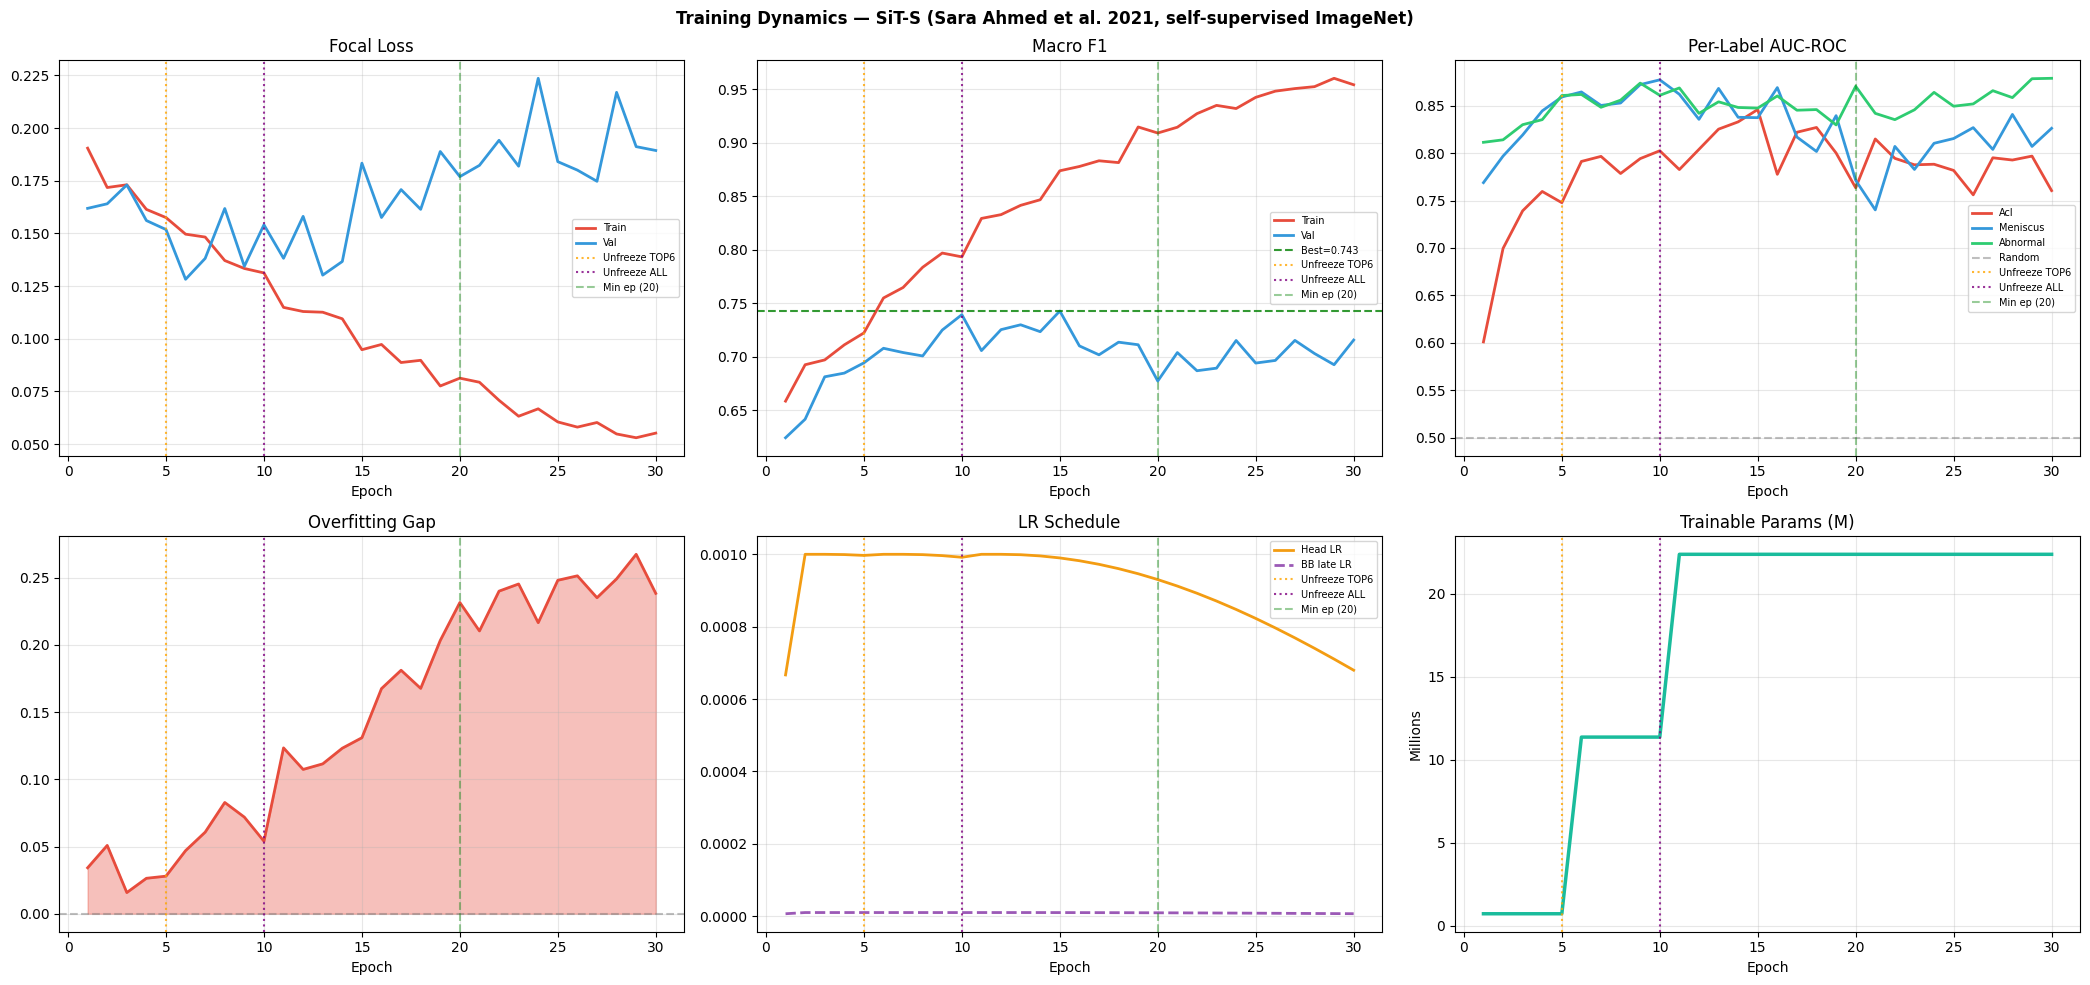

Saved → /user/HS402/mi00806/Downloads/AML/mrnet_outputs/training_curves.png


In [14]:
ep = range(1, len(history["train_loss"])+1)
fig, axes = plt.subplots(2, 3, figsize=(21, 10))
fig.suptitle(f"Training Dynamics — {model.pretrained_source}",
             fontsize=12, fontweight="bold")

def add_stages(ax):
    ax.axvline(CFG.UNFREEZE_PARTIAL_EP, color="orange", linestyle=":", alpha=0.8,
               label=f"Unfreeze TOP{CFG.N_BLOCKS_PARTIAL}")
    ax.axvline(CFG.UNFREEZE_FULL_EP, color="purple", linestyle=":", alpha=0.8,
               label="Unfreeze ALL")
    ax.axvline(CFG.MIN_EPOCHS, color="green", linestyle="--", alpha=0.4,
               label=f"Min ep ({CFG.MIN_EPOCHS})")

axes[0,0].plot(ep, history["train_loss"], label="Train", color="#E74C3C", lw=2)
axes[0,0].plot(ep, history["val_loss"],   label="Val",   color="#3498DB", lw=2)
add_stages(axes[0,0]); axes[0,0].set_title("Focal Loss")
axes[0,0].legend(fontsize=7); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ep, history["train_f1"], label="Train", color="#E74C3C", lw=2)
axes[0,1].plot(ep, history["val_f1"],   label="Val",   color="#3498DB", lw=2)
axes[0,1].axhline(best_val_f1, color="green", linestyle="--",
                  label=f"Best={best_val_f1:.3f}", alpha=0.8)
add_stages(axes[0,1]); axes[0,1].set_title("Macro F1")
axes[0,1].legend(fontsize=7); axes[0,1].grid(alpha=0.3)

for name, col in zip(CFG.LABEL_NAMES, ["#E74C3C","#3498DB","#2ECC71"]):
    axes[0,2].plot(ep, history[f"auc_{name}"], label=name.capitalize(), color=col, lw=2)
axes[0,2].axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random")
add_stages(axes[0,2]); axes[0,2].set_title("Per-Label AUC-ROC")
axes[0,2].legend(fontsize=7); axes[0,2].grid(alpha=0.3)

gap = [t-v for t,v in zip(history["train_f1"], history["val_f1"])]
axes[1,0].fill_between(ep, 0, gap, alpha=0.35, color="#E74C3C")
axes[1,0].plot(ep, gap, color="#E74C3C", lw=2)
axes[1,0].axhline(0, color="gray", linestyle="--", alpha=0.5)
add_stages(axes[1,0]); axes[1,0].set_title("Overfitting Gap")
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ep, history["lr_head"],    label="Head LR",    color="#F39C12", lw=2)
axes[1,1].plot(ep, history["lr_bb_late"], label="BB late LR", color="#9B59B6", lw=2, ls="--")
add_stages(axes[1,1]); axes[1,1].set_title("LR Schedule")
axes[1,1].legend(fontsize=7); axes[1,1].grid(alpha=0.3)

axes[1,2].plot(ep, [p/1e6 for p in history["trainable"]], color="#1ABC9C", lw=2.5)
axes[1,2].axvline(CFG.UNFREEZE_PARTIAL_EP, color="orange", linestyle=":", alpha=0.8)
axes[1,2].axvline(CFG.UNFREEZE_FULL_EP,    color="purple", linestyle=":", alpha=0.8)
axes[1,2].set_title("Trainable Params (M)"); axes[1,2].set_ylabel("Millions")
axes[1,2].grid(alpha=0.3)

for ax in axes.flat: ax.set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(CFG.OUT_DIR/"training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {CFG.OUT_DIR/'training_curves.png'}")
